(sec:alpha)=
# Polarizability

The calculation of molecular polarizabilities in VeloxChem is based on linear‑response theory, where the induced dipole moment is evaluated as a function of an external electric field to obtain the polarizability tensor. Starting from the ground state DFT reference, the frequency‑dependent response equations are solved to provide both static and dynamic polarizabilities, which serve as the foundation for describing optical properties such as refractive indices and light‑scattering behavior.

The linear electric-dipole polarizabilty is determined from the linear response function 

$$
\alpha_{\alpha\beta}(\omega) =
- 
\langle\langle \hat{\mu}_\alpha; \hat{\mu}_\beta 
\rangle \rangle_\omega
$$

where $\hat{\mu}_\alpha$ is the electric-dipole operator along Cartesian axis $\alpha$ and $\omega$ is the optical angular frequency. For randomly oriented samples, the relevant quantity is the isotropic polarizability

$$
\overline{\alpha}(\omega) = 
\frac{1}{3}
\big[
\alpha_{xx}(\omega) +
\alpha_{yy}(\omega) +
\alpha_{zz}(\omega)
\big]
$$

The atomic unit of polarizability is

$$
1 e^2 a_0^2 E_h^{-1}
$$

At optical frequencies well separated from transition frequencies in the system, the polarizability is real, whereas in near-resonance or resonance regions of the spectrum, it becomes complex. For further theoretical details, see {cite}`Norman2018`.

(sec:nonres-region)=
## Nonresonant region

In the nonresonant region, where the driving field lies far from any electronic transition, the molecular polarizability varies smoothly with frequency, and the response is dominated by elastic Rayleigh scattering arising from the real part of the polarizability tensor, while the imaginary component remains vanishingly small due to the absence of absorption.

**Python script**

In [1]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("methane")
basis = vlx.MolecularBasis.read(molecule, "def2-svpd")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

lr_drv = vlx.LinearResponseSolver()

lr_drv.property = "polarizability"
lr_drv.frequencies = [0.0, 0.0656]  # static field is default

lr_results = lr_drv.compute(molecule, basis, scf_results)

Reading methane from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Invers

In [2]:
print("Frequency      Polarizability (isotropic)")

for freq in lr_drv.frequencies:
    alpha_iso = 0
    for comp in "xyz":
        alpha_iso += lr_results["response_functions"][(comp, comp, freq)]
    alpha_iso = -alpha_iso / 3

    print(f"{freq:.4f} a.u. {alpha_iso:10.4f} a.u.")

Frequency      Polarizability (isotropic)
0.0000 a.u.    17.2294 a.u.
0.0656 a.u.    17.5029 a.u.


**Text file**

:::{code}
@jobs
task: response
@end

@method settings
basis: aug-cc-pvdz
@end

@response
property: polarizability
frequencies: 0-0.25 (0.05)
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end 
:::

(sec:res-region)=
## Resonant region

In the resonant region, the molecular polarizability exhibits strong frequency dependence as the probing field approaches an electronic transition, leading to large dispersive features in the real part and the emergence of an imaginary component directly associated with absorption and radiative damping processes.

**Python script**

In [23]:
import numpy as np
import veloxchem as vlx

molecule = vlx.Molecule.read_name("methane")
basis = vlx.MolecularBasis.read(molecule, "def2-svpd")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

crs = vlx.ComplexResponse()

# to be implemented (together with a plot function)
# crs.property = "polarizability"

crs.a_operator = "electric dipole"
crs.b_operator = "electric dipole"

crs.a_components = ["x", "y", "z"]
crs.b_components = ["x", "y", "z"]

crs.frequencies = np.arange(0.3, 0.42, 0.0025)

crs_results = crs.compute(molecule, basis, scf_results)

Reading methane from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Invers

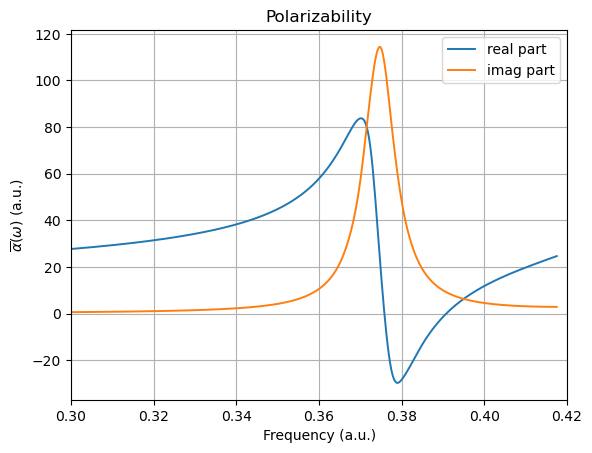

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline

alpha_iso = []
for freq in crs.frequencies:
    diag = 0
    for comp in "xyz":
        key = (comp, comp, freq)
        diag += crs_results["response_functions"][key]
    alpha_iso.append(-diag/3)

alpha_iso = np.array(alpha_iso)

alpha_real = alpha_iso.real
alpha_imag = alpha_iso.imag

freqs = np.array(crs.frequencies)

# Cubic spline interpolation
cs_real = CubicSpline(freqs, alpha_real)
cs_imag = CubicSpline(freqs, alpha_imag)

# Dense grid for smooth curves
f_dense = np.linspace(freqs.min(), freqs.max(), 400)

# Create figure and axis
fig, ax = plt.subplots()

# --- Smooth cubic-spline curves ---
ax.plot(f_dense, cs_real(f_dense), "-", linewidth=1.4, label="real part")
ax.plot(f_dense, cs_imag(f_dense), "-", linewidth=1.4, label="imag part")

ax.set_xlim(0.3, 0.42)
plt.title("Polarizability")
ax.set_xlabel("Frequency (a.u.)")
ax.set_ylabel(r"$\overline{\alpha}(\omega)$ (a.u.)")
ax.grid(True)
ax.legend()

plt.show()